In [1]:
from ihp import PDK
from ihp.cells.capacitors import cmom
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

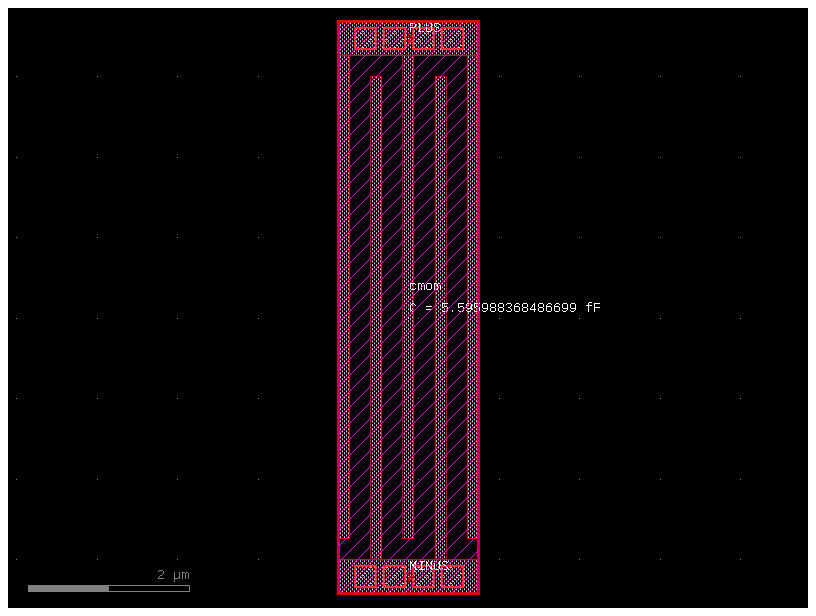

In [2]:
c = cmom(nfingers=2, length=6.0)

cc = c.copy()
cc.draw_ports()

cc.plot()

In [ ]:
# Checking the port layers.
c.ports

["Port(self.name='PLUS', self.width=140, trans=r0 *1 0.87,6.47, layer=Metal3pin (30/2), port_type=electrical)", "Port(self.name='MINUS', self.width=140, trans=r0 *1 0.87,-0.21, layer=Metal3pin (30/2), port_type=electrical)"]

In [4]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-cmom")
sim.set_geometry(c)

sim.set_stack(substrate_thickness=1.0, air_above=0.5)

sim.add_port("PLUS",from_layer="metal1",to_layer="metal3", geometry="via",excited=True)
sim.add_port("MINUS",from_layer="metal1",to_layer="metal3",geometry="via",excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
# TODO: investigate why Z dimension is much larger than expected.
# The full IHP stack inflates the domain, air_above and layer filtering don't seem to help —
# likely get_stack() pre-computes a fixed zmax/bbox independent of stack.layers.

sim.mesh(preset="graded",margin=0.5, refined_mesh_size=0.2)

Mesh Summary
Dimensions: 2.7 x 8.1 x 17.8 µm
Nodes:      5,808
Elements:   45,273
Tetrahedra: 31,869
Edge length: 0.09 - 8.56 µm
Quality:    0.623 (min: 0.016)
SICN:       0.662 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (13):
  - metal1_xy [4]
  - metal1_z [5]
  - metal2_xy [6]
  - metal2_z [7]
  - metal3_xy [8]
  - metal3_z [9]
  - P1 [10]
  - P2 [11]
  - SiO2__None [12]
  - SiO2__passive [13]
  - passive__None [14]
  - air__passive [15]
  - air__None [16]
----------------------------------------
Mesh:   runs/palace-sim-cmom/palace.msh

2026-03-17 15:19:45.195 (   2.566s) [    7C0275C4E080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 15:19:45.206 (   2.577s) [    7C0275C4E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 15:19:45.222 (   2.593s) [    7C0275C4E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

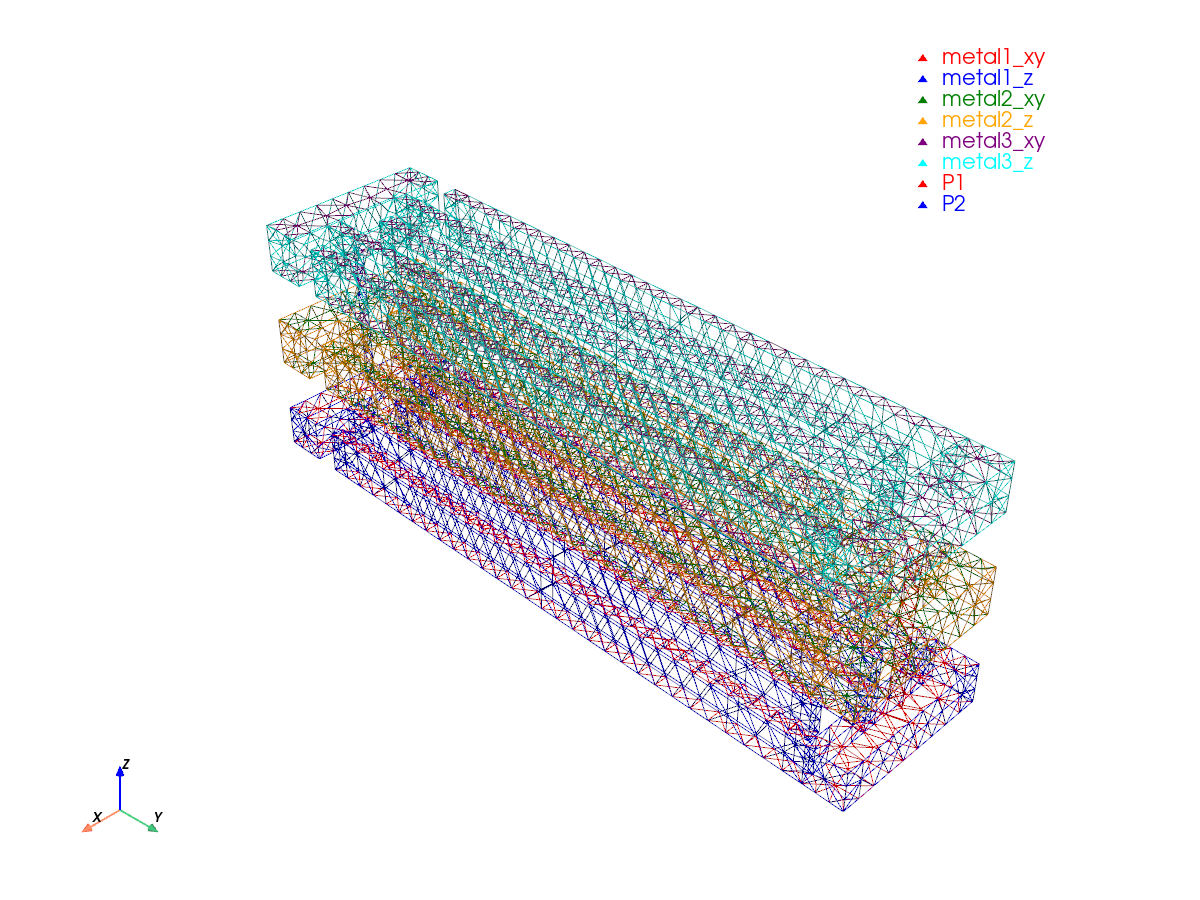

In [6]:
sim.plot_mesh(show_groups=["metal","P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 15:19:45.555 (   2.926s) [    7C0275C4E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 15:19:45.566 (   2.937s) [    7C0275C4E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 15:19:45.597 (   2.968s) [    7C0275C4E080]vt

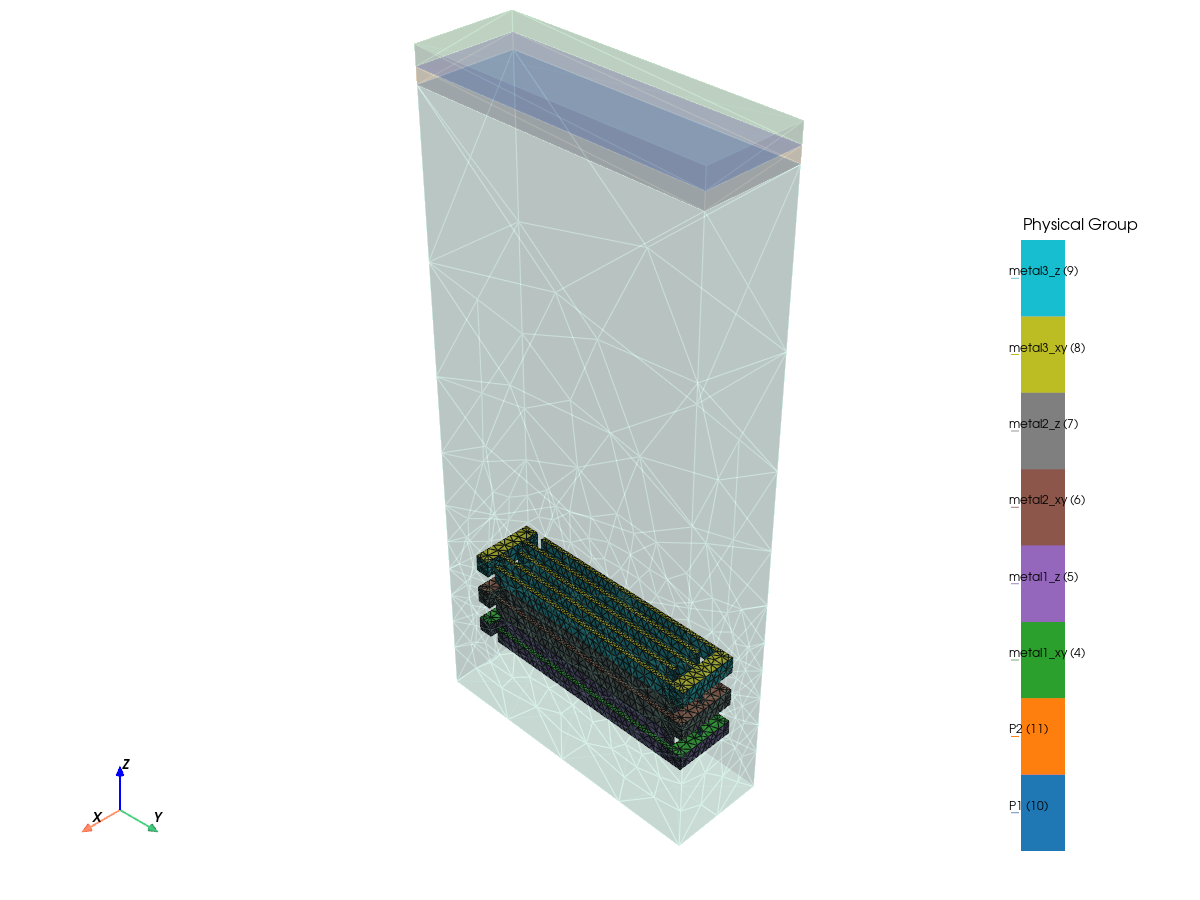

In [7]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["passive__None","air__None","air__passive","SiO2__None","SiO2__passive"],
)

In [8]:
results = sim.run(parent_dir="runs")

  palace-cc0d6b8e  completed  0m 40s
Extracting results.tar.gz...
Downloaded 6 files to runs/sim-data-palace-cc0d6b8e


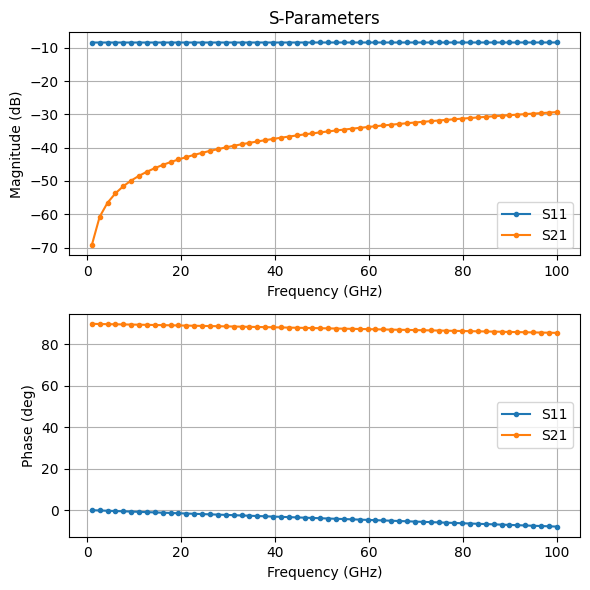

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()